In [1]:
# Suppress warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'
os.environ['MEDIAPIPE_DISABLE_GPU'] = '1'

In [2]:
# Import packages
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import PoseLandmarker, PoseLandmarkerOptions
from mediapipe.tasks.python import BaseOptions
import pandas as pd
from tqdm import tqdm
import urllib.request
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt

In [3]:
# Configure directories
UCF_VIDEOS = "UCF-101"
UCF_SPLITS = "UCF101TrainTestSplits/ucfTrainTestlist"
FRAMES_DIR = "outputs/frames"
KEYPOINTS_DIR = "outputs/keypoints"

# Convert UCF101 classes to our labels
EXERCISE_CLASSES = {
    "PushUps": "pushups", 
    "BodyWeightSquats": "squats",
    "Lunges": "lunges",
    "PullUps": "pullups",
}

# Configure desired frame rates and image size
TARGET_FPS = 10
IMG_SIZE = (640, 480)

In [4]:
# Filter 5 classes from the train/test split

def load_videos():
    rows = []
    for split, filename in [("train", "trainlist01.txt"), ("test", "testlist01.txt")]:
        filepath = os.path.join(UCF_SPLITS, filename)
        with open(filepath) as f:
            for line in f: # e.g. BodyWeightSquats/v_BodyWeightSquats_g08_c01.avi
                rel_path = line.strip().split()[0]
                class_name = rel_path.split("/")[0]
                if class_name not in EXERCISE_CLASSES:
                    continue
                rows.append({
                    "video_path": os.path.join(UCF_VIDEOS, rel_path),
                    "label": EXERCISE_CLASSES[class_name],
                    "split": split,
                    "video_name": os.path.splitext(os.path.basename(rel_path))[0]
                })
    df = pd.DataFrame(rows)
    print(f"Found {len(df)} exercise videos\n{df['label'].value_counts()}\n")
    return df

In [5]:
# Extract frames from the videos
def extract_frames(video_df):
    rows = []
    for _, row in tqdm(video_df.iterrows(), total=len(video_df), desc="Extracting keyframes"):
        save_dir = os.path.join(FRAMES_DIR, row["split"], row["label"], row["video_name"])
        os.makedirs(save_dir, exist_ok=True)

        # Use OpenCV to open the .avi file
        # Checks the video's native FPS and determines how many frames to get based on that
        cap = cv2.VideoCapture(row["video_path"])
        fps = cap.get(cv2.CAP_PROP_FPS) or TARGET_FPS
        frame_interval = max(1, int(round(fps / TARGET_FPS)))

        frame_idx = 0 # Tracks every frame seens
        saved_idx = 0 # Tracks only the frames to save

        while True:
            ret, frame = cap.read()
            if not ret:
                break # Ret = False once the video has ended, so break
            if frame_idx % frame_interval == 0: # Resize and save frames in wanted interval
                frame_path = os.path.join(save_dir, f"frame_{saved_idx:04d}.jpg")
                cv2.imwrite(frame_path, cv2.resize(frame, IMG_SIZE))
                rows.append({**row, "frame_path": frame_path, "frame_index": saved_idx})
                saved_idx += 1
            frame_idx += 1
        cap.release() # Closes the video
    df = pd.DataFrame(rows)
    print(f"Extracted {len(df)} frames total\n")
    return df

In [6]:
# Name keypoints according to MediaPipe Pose standards
KEYPOINT_NAMES = [
    "nose", "left_eye_inner", "left_eye", "left_eye_outer",
    "right_eye_inner", "right_eye", "right_eye_outer",
    "left_ear", "right_ear", "mouth_left", "mouth_right",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_pinky", "right_pinky",
    "left_index", "right_index", "left_thumb", "right_thumb",
    "left_hip", "right_hip", "left_knee", "right_knee",
    "left_ankle", "right_ankle", "left_heel", "right_heel",
    "left_foot_index", "right_foot_index",
]

# Download the MediaPipe Pose model
MODEL_PATH = "pose_landmarker.task"
if not os.path.exists(MODEL_PATH):
    print("Downloading pose model...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task",
        MODEL_PATH
    )
    print("Downloaded!")

# Extract keypoints 
def extract_keypoints(frame_df):
    os.makedirs(KEYPOINTS_DIR, exist_ok=True)
    options = PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_poses=1,
        min_pose_detection_confidence=0.5,
    )
    rows = []
    with PoseLandmarker.create_from_options(options) as landmarker:
        # Loop through each frame in the dataframe
        for _, row in tqdm(frame_df.iterrows(), total=len(frame_df), desc="Pose estimation"):
            frame = cv2.imread(row["frame_path"])
            if frame is None:
                continue
            
            # Run MediaPipe on the frame after converting to RGB
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            results = landmarker.detect(mp_image)
            if not results.pose_landmarks:
                continue

            landmarks = results.pose_landmarks[0]
            keypoints = {}
            for i, name in enumerate(KEYPOINT_NAMES):
                kp = landmarks[i]
                # x and y-> position on screen
                keypoints[f"{name}_x"]   = round(kp.x, 6)
                keypoints[f"{name}_y"]   = round(kp.y, 6)

            rows.append({
                "frame_path": row["frame_path"],
                "video_name": row["video_name"],
                "label": row["label"],
                "split": row["split"],
                "frame_index": row["frame_index"],
                **keypoints # Append entire keyframes dictionary at once
            })

    df = pd.DataFrame(rows)
    # Output two CSVs that the model will train on (train and test keypoints)
    for split, group in df.groupby("split"):
        out_path = os.path.join(KEYPOINTS_DIR, f"{split}_keypoints.csv")
        group.to_csv(out_path, index=False)
        print(f"Saved {len(group)} rows → {out_path}")
        print(group["label"].value_counts(), "\n")
    return df

In [7]:
video_df = load_videos()
frame_df = extract_frames(video_df)
extract_keypoints(frame_df)

Found 441 exercise videos
label
lunges     127
squats     112
pushups    102
pullups    100
Name: count, dtype: int64



Extracting keyframes: 100%|██████████| 441/441 [01:08<00:00,  6.43it/s]
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773008254.907895   25681 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773008254.928753   25681 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Extracted 30542 frames total



Pose estimation: 100%|██████████| 30542/30542 [25:09<00:00, 20.24it/s]


Saved 6682 rows → outputs/keypoints/test_keypoints.csv
label
lunges     2953
squats     1812
pushups     980
pullups     937
Name: count, dtype: int64 

Saved 19003 rows → outputs/keypoints/train_keypoints.csv
label
lunges     8562
squats     5312
pullups    2818
pushups    2311
Name: count, dtype: int64 



,frame_path,video_name,label,split,frame_index,nose_x,nose_y,left_eye_inner_x,left_eye_inner_y,left_eye_x,...,right_ankle_x,right_ankle_y,left_heel_x,left_heel_y,right_heel_x,right_heel_y,left_foot_index_x,left_foot_index_y,right_foot_index_x,right_foot_index_y
0,outputs/frames/train/squats/v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,0,0.498673,0.326496,0.498823,0.310231,0.500799,...,0.418064,0.926530,0.502136,0.951584,0.416596,0.943307,0.521351,0.987317,0.437229,0.987532
1,outputs/frames/train/squats/v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,1,0.500553,0.326977,0.500588,0.310929,0.502863,...,0.416375,0.922343,0.515113,0.950880,0.417114,0.942618,0.539038,0.987219,0.431648,0.986855
2,outputs/frames/train/squats/v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,2,0.499821,0.333189,0.499326,0.315810,0.501401,...,0.418779,0.929287,0.501735,0.939598,0.416613,0.949758,0.534165,0.994338,0.434126,0.993847
3,outputs/frames/train/squats/v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,3,0.498956,0.325757,0.499175,0.310002,0.501396,...,0.416944,0.929215,0.502683,0.939826,0.408780,0.947274,0.539876,0.989183,0.434386,0.992563
4,outputs/frames/train/squats/v_BodyWeightSquats...,v_BodyWeightSquats_g08_c01,squats,train,4,0.502801,0.319948,0.501783,0.304822,0.503626,...,0.414610,0.930649,0.514346,0.958495,0.416564,0.932616,0.542548,0.990173,0.433984,0.993988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25680,outputs/frames/test/pushups/v_PushUps_g07_c04/...,v_PushUps_g07_c04,pushups,test,33,0.491822,0.741267,0.504495,0.722627,0.511713,...,0.463985,0.596946,0.560528,0.595305,0.465712,0.575670,0.560049,0.663210,0.476373,0.633471
25681,outputs/frames/test/pushups/v_PushUps_g07_c04/...,v_PushUps_g07_c04,pushups,test,34,0.459917,0.625077,0.474911,0.611540,0.480249,...,0.450164,0.766832,0.518346,0.703924,0.450639,0.755107,0.536345,0.724376,0.461991,0.794698
25682,outputs/frames/test/pushups/v_PushUps_g07_c04/...,v_PushUps_g07_c04,pushups,test,36,0.485812,0.422343,0.497949,0.404238,0.503410,...,0.421079,0.497352,0.525132,0.510575,0.430625,0.484128,0.556685,0.577508,0.427770,0.554399
25683,outputs/frames/test/pushups/v_PushUps_g07_c04/...,v_PushUps_g07_c04,pushups,test,37,0.474141,0.419555,0.489613,0.402007,0.495637,...,0.405638,0.473384,0.535101,0.495026,0.414526,0.468360,0.567125,0.551293,0.405253,0.512134


In [8]:
# Delete unnecessary keypoints
useful_keypoints = [
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle", 
    "nose", "left_ear", "right_ear"
]

train_df = pd.read_csv("outputs/keypoints/train_keypoints.csv")
keep_cols = ["frame_path", "video_name", "label", "split", "frame_index"]
for kp in useful_keypoints:
    keep_cols += [f"{kp}_x", f"{kp}_y"]

train_df = train_df[keep_cols]
train_df.to_csv("outputs/keypoints/train_keypoints.csv", index=False)

test_df = pd.read_csv("outputs/keypoints/test_keypoints.csv")
keep_cols = ["frame_path", "video_name", "label", "split", "frame_index"]
for kp in useful_keypoints:
    keep_cols += [f"{kp}_x", f"{kp}_y"]

test_df = test_df[keep_cols]
test_df.to_csv("outputs/keypoints/test_keypoints.csv", index=False)

## Feature Computation and Labeling

In [9]:
def compute_angle(a, b, c):
    """Angle at point b, formed by a-b-c"""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

def compute_torso_angle(row):
    """
    Angle of torso from vertical.
    0° = perfectly upright, 90° = horizontal
    """
    shoulder_mid_x = (row["left_shoulder_x"] + row["right_shoulder_x"]) / 2
    shoulder_mid_y = (row["left_shoulder_y"] + row["right_shoulder_y"]) / 2
    hip_mid_x      = (row["left_hip_x"]      + row["right_hip_x"])      / 2
    hip_mid_y      = (row["left_hip_y"]      + row["right_hip_y"])      / 2

    # Vector from hip to shoulder
    dx = shoulder_mid_x - hip_mid_x
    dy = shoulder_mid_y - hip_mid_y  # note: y increases downward in image coords

    # Angle from vertical (0° = straight up)
    angle = np.degrees(np.arctan2(abs(dx), abs(dy)))
    return angle
    
def add_angles(df):
    def angle(r, a, b, c):
        """Helper to pull x/y from row and compute angle at b"""
        return compute_angle(
            (r[f"{a}_x"], r[f"{a}_y"]),
            (r[f"{b}_x"], r[f"{b}_y"]),
            (r[f"{c}_x"], r[f"{c}_y"])
        )

    # KNEE ANGLES (squats, lunges) 
    for side in ["left", "right"]:
        df[f"{side}_knee_angle"] = df.apply(
            lambda r, s=side: angle(r, f"{s}_hip", f"{s}_knee", f"{s}_ankle"), axis=1)

    # ELBOW ANGLES (push-ups, pull-ups)
    for side in ["left", "right"]:
        df[f"{side}_elbow_angle"] = df.apply(
            lambda r, s=side: angle(r, f"{s}_shoulder", f"{s}_elbow", f"{s}_wrist"), axis=1)

    # HIP ANGLES (squats, lunges, pull-ups)
    for side in ["left", "right"]:
        df[f"{side}_hip_angle"] = df.apply(
            lambda r, s=side: angle(r, f"{s}_shoulder", f"{s}_hip", f"{s}_knee"), axis=1)

    # BODY LINE / HIP SAG (push-ups)
    for side in ["left", "right"]:
        df[f"{side}_body_line"] = df.apply(
            lambda r, s=side: angle(r, f"{s}_shoulder", f"{s}_hip", f"{s}_ankle"), axis=1)

    # TORSO UPRIGHTNESS (lunges, squats)
    # Angle between vertical and the shoulder-hip vector
    df["torso_angle"] = df.apply(compute_torso_angle, axis=1)

    # KNEE BEND (squats, lunges)
    # How far knee is inside/outside the ankle - not an angle, just a distance
    for side in ["left", "right"]:
        df[f"{side}_knee_bend"] = df[f"{side}_knee_x"] - df[f"{side}_ankle_x"]

    # HEAD DROP (push-ups) 
    df["head_drop"] = df["nose_y"] - df["left_shoulder_y"]

    # SHOULDER SHRUG (pull-ups)
    for side in ["left", "right"]:
        df[f"{side}_shoulder_shrug"] = df[f"{side}_ear_y"] - df[f"{side}_shoulder_y"]

    # SHOULDER ANGLE (pull-ups)
    for side in ["left", "right"]:
        df[f"{side}_shoulder_angle"] = df.apply(
        lambda r, s=side: angle(r, f"{s}_elbow", f"{s}_shoulder", f"{s}_hip"), axis=1)
    return df

In [10]:
def detect_orientation(row):
    shoulder_sep = abs(row["left_shoulder_x"] - row["right_shoulder_x"])
    hip_sep      = abs(row["left_hip_x"]      - row["right_hip_x"])
    avg_sep      = (shoulder_sep + hip_sep) / 2
    # Lowered from 0.15 — your data maxes out at ~0.27
    return "front" if avg_sep > 0.08 else "side"


def label_form(row):
    label       = row.get("label")
    orientation = detect_orientation(row)

    lk  = row.get("left_knee_angle",       180)
    rk  = row.get("right_knee_angle",      180)
    le  = row.get("left_elbow_angle",      180)
    re  = row.get("right_elbow_angle",     180)
    lbl = row.get("left_body_line",        180)
    rbl = row.get("right_body_line",       180)
    tor = row.get("torso_angle",           0)
    lkb = row.get("left_knee_bend",        0)
    rkb = row.get("right_knee_bend",       0)
    lss = row.get("left_shoulder_shrug",   0)
    rss = row.get("right_shoulder_shrug",  0)
    hd  = row.get("head_drop",             0)
    lh  = row.get("left_hip_angle",        180)
    rh  = row.get("right_hip_angle",       180)

    min_knee      = min(lk, rk)
    min_elbow     = min(le, re)
    knee_sym      = abs(lk - rk)
    elbow_sym     = abs(le - re)
    avg_body_line = (lbl + rbl) / 2
    avg_shrug     = (lss + rss) / 2

    # Filter out bad landmark detections
    # 180° means mediapipe lost the joint
    if min_knee > 179 or min_elbow > 179:
        return None

    # ── SQUATS ───────────────────────────────────────────────
    # Data shows knee angles: 25%=111, 50%=149, 75%=171
    # Good = clearly bent (bottom) or clearly straight (top)
    if label == "squats":
        at_bottom = min_knee < 130        # adjusted from 110
        at_top    = min_knee > 165        # adjusted from 160
        if not (at_bottom or at_top):
            return "bad"

        leaning   = tor > 30
        knee_cave = (lkb < -0.04 or rkb < -0.04)

        if orientation == "front":
            asymmetric = knee_sym > 25
            return "bad" if (leaning or knee_cave or asymmetric) else "good"
        else:
            return "bad" if (leaning or knee_cave) else "good"

    # ── PUSHUPS ──────────────────────────────────────────────
    # Data shows elbow angles: 25%=98, 50%=128, 75%=164
    elif label == "pushups":
        at_bottom = min_elbow < 120       # adjusted from 110
        at_top    = min_elbow > 155
        if not (at_bottom or at_top):
            return "bad"

        hip_sag   = avg_body_line < 145
        head_down = hd > 0.12
        asymmetric = elbow_sym > 25

        if orientation == "front":
            return "bad" if (hip_sag or head_down or asymmetric) else "good"
        else:
            return "bad" if (hip_sag or head_down) else "good"

    # ── LUNGES ───────────────────────────────────────────────
    # Data shows knee angles: 25%=132, 50%=166, 75%=176
    # Wide spread means we're catching full movement range
    elif label == "lunges":
        at_top   = min_knee > 165
        at_depth = min_knee < 140         # adjusted — lunges don't go as deep as squats

        if not (at_top or at_depth):
            return "bad"

        leaning   = tor > 20
        knee_over = (lkb > 0.08 or rkb > 0.08)

        if orientation == "front":
            naturally_asym = knee_sym > 15
            return "bad" if (leaning or knee_over or not naturally_asym) else "good"
        else:
            return "bad" if (leaning or knee_over) else "good"

    # ── PULLUPS ──────────────────────────────────────────────
    # Data shows elbow angles: 25%=73, 50%=144, 75%=168
    # Wide spread — good, we're catching full hang-to-pull range
    elif label == "pullups":
        at_top  = min_elbow < 110         # adjusted from 90
        at_hang = min_elbow > 150
        if not (at_top or at_hang):
            return "bad"

        shrugging  = avg_shrug > -0.02
        asymmetric = elbow_sym > 25
        swinging   = abs(lh - rh) > 30

        if orientation == "front":
            return "bad" if (shrugging or asymmetric or swinging) else "good"
        else:
            return "bad" if (shrugging or swinging) else "good"

    return None

def apply_labels(df):
    df = add_angles(df)
    df["orientation"] = df.apply(detect_orientation, axis=1)
    df["form_label"]  = df.apply(label_form, axis=1)
    df = df.dropna(subset=["form_label"])
    return df

In [11]:
train_df = pd.read_csv("outputs/keypoints/train_keypoints.csv")
test_df  = pd.read_csv("outputs/keypoints/test_keypoints.csv")

train_df = apply_labels(train_df)
test_df  = apply_labels(test_df)

print(train_df.groupby(["label", "orientation", "form_label"]).size())
print(f"\nTotal remaining: {len(train_df)}")
print(f"Null form_labels: {train_df['form_label'].isna().sum()}")

label    orientation  form_label
lunges   front        bad           1834
                      good           526
         side         bad           1795
                      good          4244
pullups  front        bad            277
                      good           533
         side         bad            587
                      good          1399
pushups  front        bad            658
                      good           186
         side         bad            688
                      good           777
squats   front        bad            351
                      good           515
         side         bad           1983
                      good          2405
dtype: int64

Total remaining: 18758
Null form_labels: 0


In [12]:
print(f"Raw CSV rows:        19003")
print(f"After apply_labels:  {len(train_df)}")
print(f"Dropped (bad landmarks): {19003 - len(train_df)}")
print(f"\nGood % per exercise:")
for ex in ["squats", "lunges", "pushups", "pullups"]:
    sub = train_df[train_df["label"] == ex]
    good = (sub["form_label"] == "good").sum()
    total = len(sub)
    print(f"  {ex:10s}: {good}/{total} = {good/total*100:.1f}%")

Raw CSV rows:        19003
After apply_labels:  18758
Dropped (bad landmarks): 245

Good % per exercise:
  squats    : 2920/5254 = 55.6%
  lunges    : 4770/8399 = 56.8%
  pushups   : 963/2309 = 41.7%
  pullups   : 1932/2796 = 69.1%


In [13]:
print(train_df.groupby(["label", "form_label"]).size())
print(test_df.groupby(["label", "form_label"]).size())

label    form_label
lunges   bad           3629
         good          4770
pullups  bad            864
         good          1932
pushups  bad           1346
         good           963
squats   bad           2334
         good          2920
dtype: int64
label    form_label
lunges   bad           1517
         good          1430
pullups  bad            160
         good           759
pushups  bad            439
         good           539
squats   bad            842
         good           949
dtype: int64


In [14]:
train_pct = train_df["label"].value_counts(normalize=True) * 100
test_pct  = test_df["label"].value_counts(normalize=True)  * 100

comparison = pd.DataFrame({"train %": train_pct, "test %": test_pct}).round(1)
print(comparison)

         train %  test %
label                   
lunges      44.8    44.4
pullups     14.9    13.9
pushups     12.3    14.7
squats      28.0    27.0


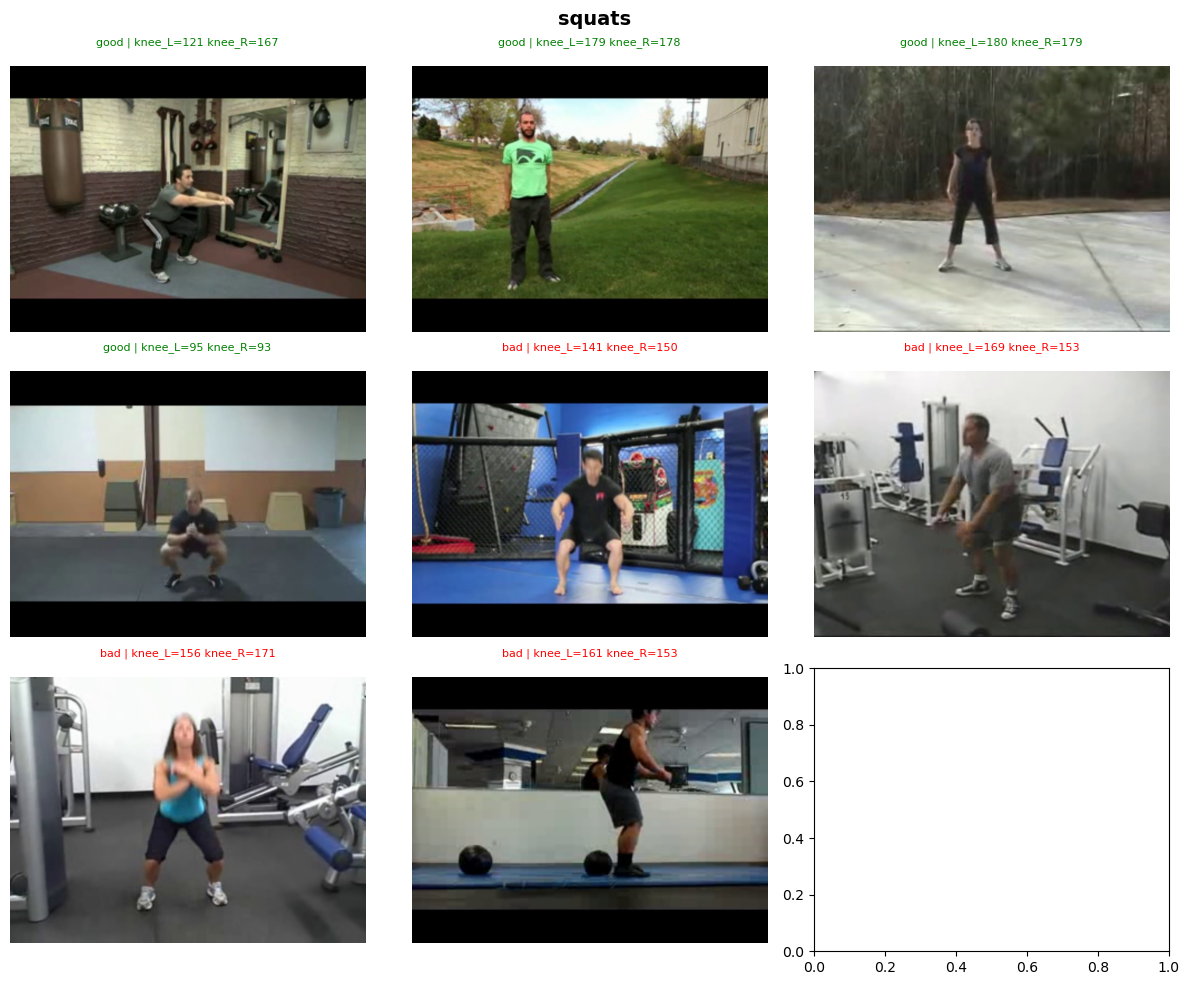

Press Enter to see next class... 


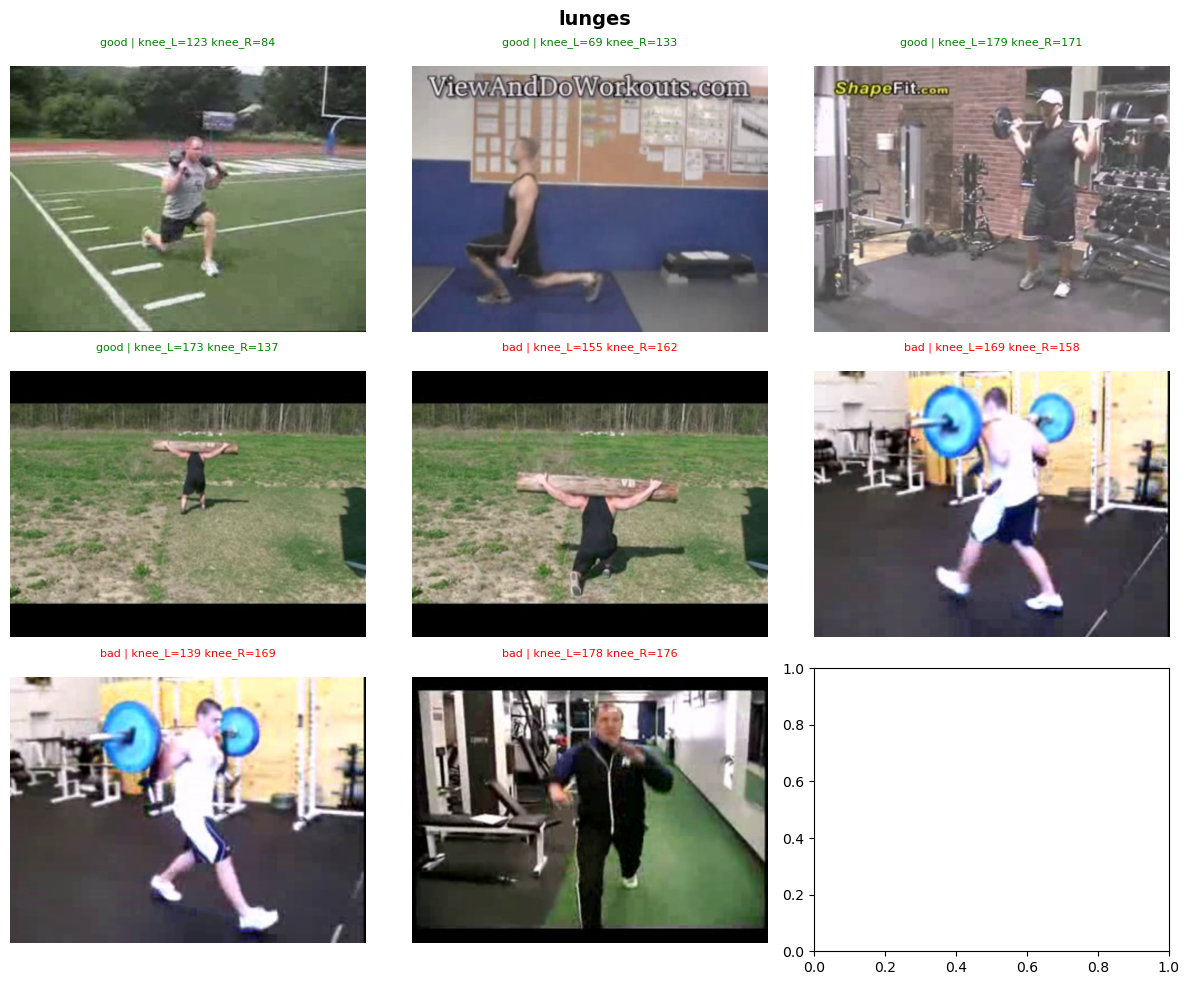

Press Enter to see next class... 


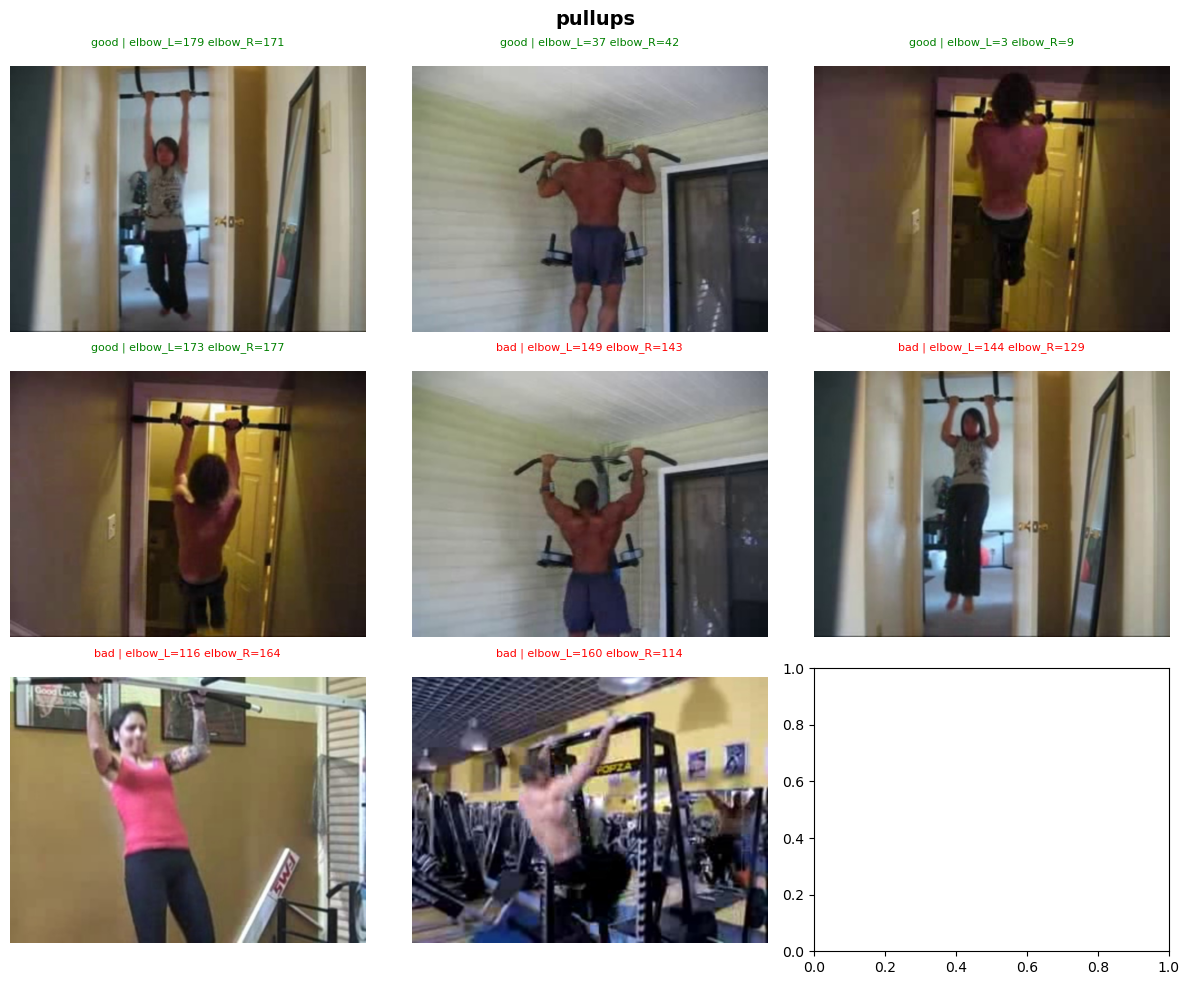

Press Enter to see next class... 


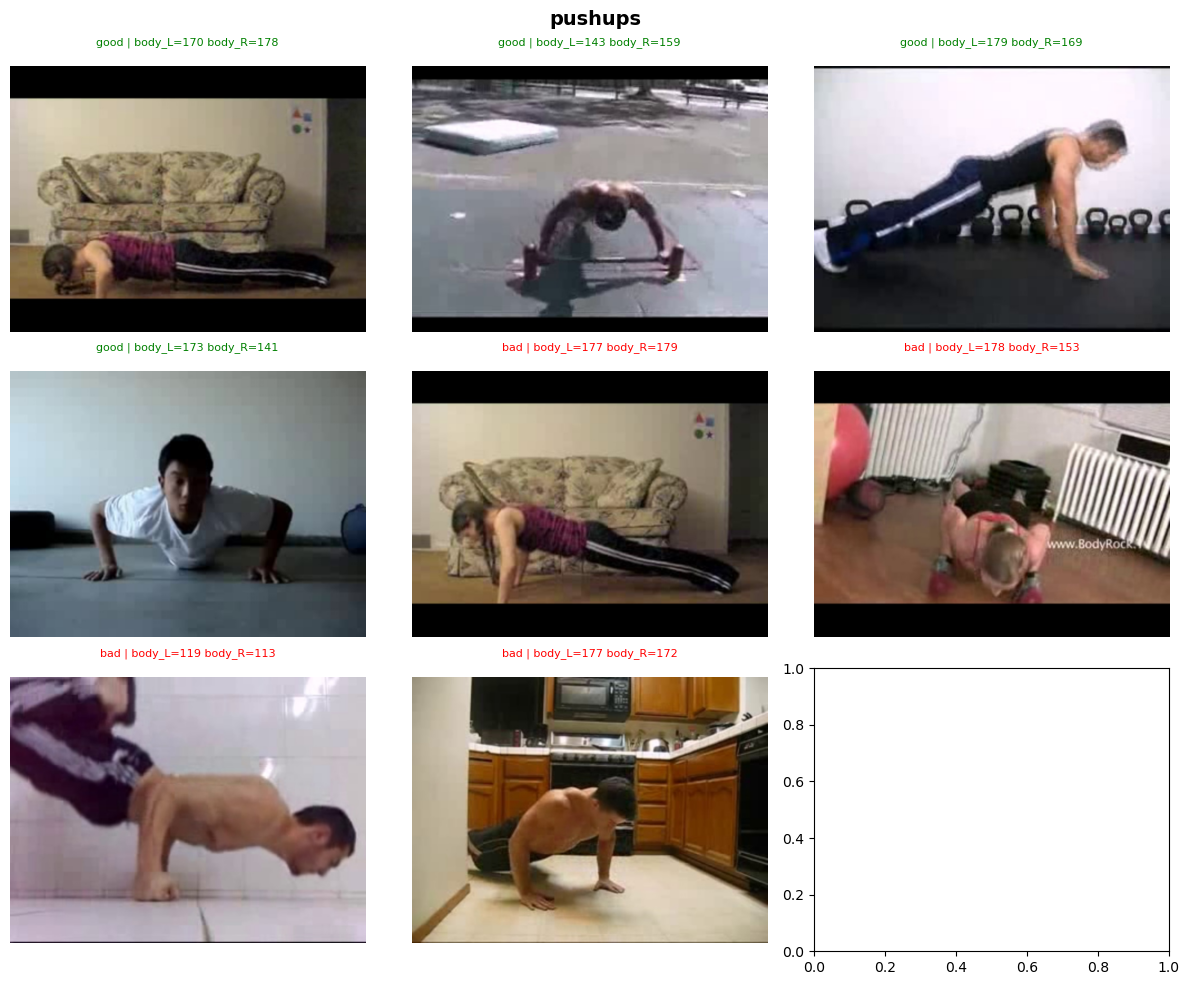

Press Enter to see next class... 


In [15]:
def visualize_labels(df, class_label, n=9):
    """
    Show n random frames for a given class label
    with the label and key feature values overlaid
    """

    good = df[(df["label"] == class_label) & (df["form_label"] == "good")]
    bad  = df[(df["label"] == class_label) & (df["form_label"] == "bad")]

    
    n_each = n // 2
    subset = pd.concat([
        good.sample(min(n_each, len(good))),
        bad.sample(min(n_each, len(bad)))
    ])

    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    fig.suptitle(class_label, fontsize=14, fontweight="bold")
    axes = axes.flatten()

    for i, (_, row) in enumerate(subset.iterrows()):
        frame = cv2.imread(row["frame_path"])
        if frame is None:
            axes[i].set_visible(False)
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame)
        axes[i].axis("off")

        # Show relevant feature values per exercise
        label = row["label"]
        if label == "squats":
            info = f"knee_L={row['left_knee_angle']:.0f} knee_R={row['right_knee_angle']:.0f}\n"
        elif label == "pushups":
            info = f"body_L={row['left_body_line']:.0f} body_R={row['right_body_line']:.0f}\n"
        elif label == "lunges":
            info = f"knee_L={row['left_knee_angle']:.0f} knee_R={row['right_knee_angle']:.0f}\n"
        elif label == "pullups":
            info = f"elbow_L={row['left_elbow_angle']:.0f} elbow_R={row['right_elbow_angle']:.0f}\n"
        else:
            info = ""

        axes[i].set_title(
            f"{row['form_label']} | {info}",
            fontsize=8,
            color="green" if row["form_label"] == "good" else "red"
        )

    plt.tight_layout()
    plt.show()


# Check each class one by one
for label in train_df["label"].unique():
    visualize_labels(train_df, label, n=9)
    input(f"Press Enter to see next class...")  # pause between classes

## Training Phase
### We used MLP to train as our features are represented by vectors instead of images (pixels) ... better explanation coming

In [16]:
# Load necessary packages
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import random

In [17]:
MODEL_DIR    = "outputs/model"
MODEL_PATH   = "pose_landmarker.task"
os.makedirs(MODEL_DIR, exist_ok=True)

FEATURE_COLS = [
    "left_knee_angle",       "right_knee_angle",
    "left_elbow_angle",      "right_elbow_angle",
    "left_hip_angle",        "right_hip_angle",
    "left_body_line",        "right_body_line",
    "left_shoulder_angle",   "right_shoulder_angle",
    "torso_angle",
    "left_knee_bend",        "right_knee_bend",
    "left_shoulder_shrug",   "right_shoulder_shrug",
    "head_drop",
]

# Feedback messages per predicted class
FEEDBACK = {
    "squats_good":            "Good squat form!",
    "squats_bad":             "Fix squat: keep knees over toes, back straight",
    "pushups_good":           "Good pushup form!",
    "pushups_bad":            "Fix pushup: keep back flat, elbows at 45 degrees",
    "lunges_good":            "Good lunge form!",
    "lunges_bad":             "Fix lunge: front knee should not pass toes, torso should be facing forward",
    "pullups_good":           "Good pullup form!",
    "pullups_bad":            "Fix pullup: full range of motion, shoulders down"
}

def load_data(train_df, test_df):
    train_df = train_df.dropna(subset=["form_label"] + FEATURE_COLS)
    test_df  = test_df.dropna(subset=["form_label"] + FEATURE_COLS)

    X_train = train_df[FEATURE_COLS].values.astype(np.float32)
    X_test  = test_df[FEATURE_COLS].values.astype(np.float32)

    y_train_raw = (train_df["label"] + "_" + train_df["form_label"]).values
    y_test_raw  = (test_df["label"]  + "_" + test_df["form_label"]).values

    le = LabelEncoder()
    le.fit(np.concatenate([y_train_raw, y_test_raw]))
    y_train = le.transform(y_train_raw)
    y_test  = le.transform(y_test_raw)

    # Normalize features to same scale
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"Training samples : {len(X_train)}")
    print(f"Test samples     : {len(X_test)}")
    print(f"Classes          : {list(le.classes_)}")
    print(f"Feature count    : {X_train.shape[1]}\n")

    return X_train, X_test, y_train, y_test, le, scaler

In [18]:
X_train, X_test, y_train, y_test, le, scaler = load_data(train_df, test_df)

Training samples : 18758
Test samples     : 6635
Classes          : ['lunges_bad', 'lunges_good', 'pullups_bad', 'pullups_good', 'pushups_bad', 'pushups_good', 'squats_bad', 'squats_good']
Feature count    : 16



In [19]:
# Model 
class PoseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class PoseMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super(PoseMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [20]:
# Training
def train_model(X_train, y_train, X_test, y_test, le,
                epochs=50, batch_size=64, lr=1e-3):

    input_dim   = X_train.shape[1]
    num_classes = len(le.classes_)
    device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}\n")

    # Datasets & loaders
    train_loader = DataLoader(PoseDataset(X_train, y_train),
                              batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(PoseDataset(X_test,  y_test),
                              batch_size=batch_size, shuffle=False)

    model     = PoseMLP(input_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

        train_loss = total_loss / total
        train_acc  = correct   / total

        # Validate 
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits   = model(X_batch)
                loss     = criterion(logits, y_batch)
                val_loss += loss.item() * len(y_batch)
                val_correct += (logits.argmax(1) == y_batch).sum().item()
                val_total   += len(y_batch)

        val_loss /= val_total
        val_acc   = val_correct / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    return model, history, device

In [21]:
# Evaluation and plots
def evaluate_model(model, X_test, y_test, le, device):
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(X_tensor).argmax(1).cpu().numpy()
    print("\n── Classification Report ──")
    print(classification_report(y_test, preds, target_names=le.classes_))

    return preds


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.legend()

    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{MODEL_DIR}/training_curves.png", dpi=150)
    plt.show()
    print(f"Saved → {MODEL_DIR}/training_curves.png")

Training on: cuda

Epoch   1/50 | Train Loss: 1.3478  Acc: 0.4760 | Val Loss: 1.1356  Acc: 0.5813
Epoch  10/50 | Train Loss: 0.8072  Acc: 0.6714 | Val Loss: 1.0970  Acc: 0.6607
Epoch  20/50 | Train Loss: 0.7321  Acc: 0.7076 | Val Loss: 1.0848  Acc: 0.6589
Epoch  30/50 | Train Loss: 0.7027  Acc: 0.7205 | Val Loss: 1.1115  Acc: 0.6705
Epoch  40/50 | Train Loss: 0.6822  Acc: 0.7319 | Val Loss: 1.1060  Acc: 0.6728
Epoch  50/50 | Train Loss: 0.6676  Acc: 0.7316 | Val Loss: 1.1368  Acc: 0.6692


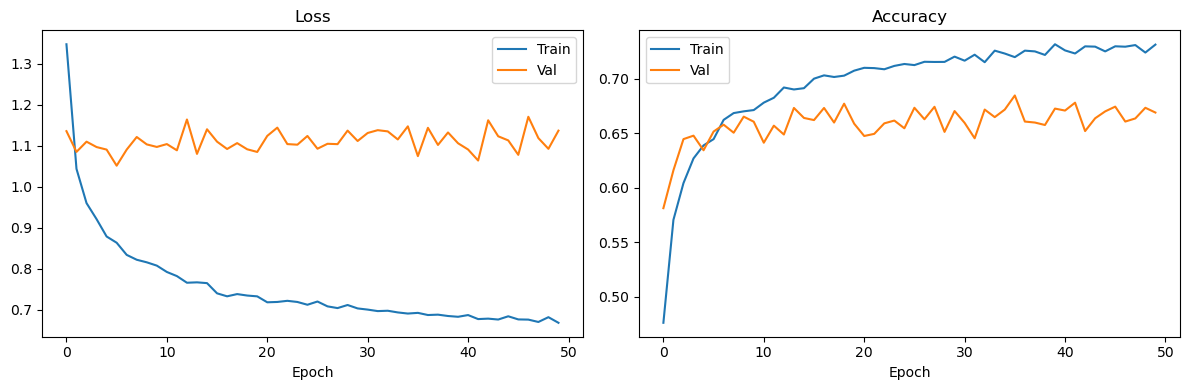

Saved → outputs/model/training_curves.png

── Classification Report ──
              precision    recall  f1-score   support

  lunges_bad       0.61      0.72      0.66      1517
 lunges_good       0.74      0.79      0.76      1430
 pullups_bad       0.15      0.28      0.20       160
pullups_good       0.76      0.71      0.73       759
 pushups_bad       0.55      0.69      0.61       439
pushups_good       0.68      0.65      0.67       539
  squats_bad       0.80      0.60      0.68       842
 squats_good       0.76      0.51      0.61       949

    accuracy                           0.67      6635
   macro avg       0.63      0.62      0.62      6635
weighted avg       0.69      0.67      0.67      6635



array([7, 7, 7, ..., 4, 4, 4])

In [22]:
model, history, device = train_model(X_train, y_train, X_test, y_test, le,
                                     epochs=50, batch_size=64, lr=1e-3)

plot_history(history)
evaluate_model(model, X_test, y_test, le, device)

# Training w/CNN

Using device: cuda
Classes     : ['lunges_bad', 'lunges_good', 'pullups_bad', 'pullups_good', 'pushups_bad', 'pushups_good', 'squats_bad', 'squats_good']
Train frames: 18758
Test frames : 6635

Epoch   1/20 | Train Loss: 0.5962  Acc: 0.7265 | Val Loss: 1.1440  Acc: 0.5316
  ✓ New best model saved (val_acc=0.5316)


/opt/conda/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:156: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch   2/20 | Train Loss: 0.3850  Acc: 0.8247 | Val Loss: 1.1582  Acc: 0.5157
Epoch   3/20 | Train Loss: 0.3248  Acc: 0.8533 | Val Loss: 1.1606  Acc: 0.5317
  ✓ New best model saved (val_acc=0.5317)
Epoch   4/20 | Train Loss: 0.2796  Acc: 0.8742 | Val Loss: 1.2124  Acc: 0.5304
Epoch   5/20 | Train Loss: 0.2429  Acc: 0.8927 | Val Loss: 1.2143  Acc: 0.5405
  ✓ New best model saved (val_acc=0.5405)
Epoch   6/20 | Train Loss: 0.2178  Acc: 0.9058 | Val Loss: 1.2634  Acc: 0.5503
  ✓ New best model saved (val_acc=0.5503)
Epoch   7/20 | Train Loss: 0.1912  Acc: 0.9181 | Val Loss: 1.4582  Acc: 0.4980
Epoch   8/20 | Train Loss: 0.1690  Acc: 0.9276 | Val Loss: 1.4661  Acc: 0.5423
Epoch   9/20 | Train Loss: 0.1533  Acc: 0.9354 | Val Loss: 1.4984  Acc: 0.4971
Epoch  10/20 | Train Loss: 0.1329  Acc: 0.9427 | Val Loss: 1.4106  Acc: 0.5492
Epoch  11/20 | Train Loss: 0.1298  Acc: 0.9456 | Val Loss: 1.5641  Acc: 0.5234
Epoch  12/20 | Train Loss: 0.1125  Acc: 0.9531 | Val Loss: 1.5731  Acc: 0.5195
Epoch

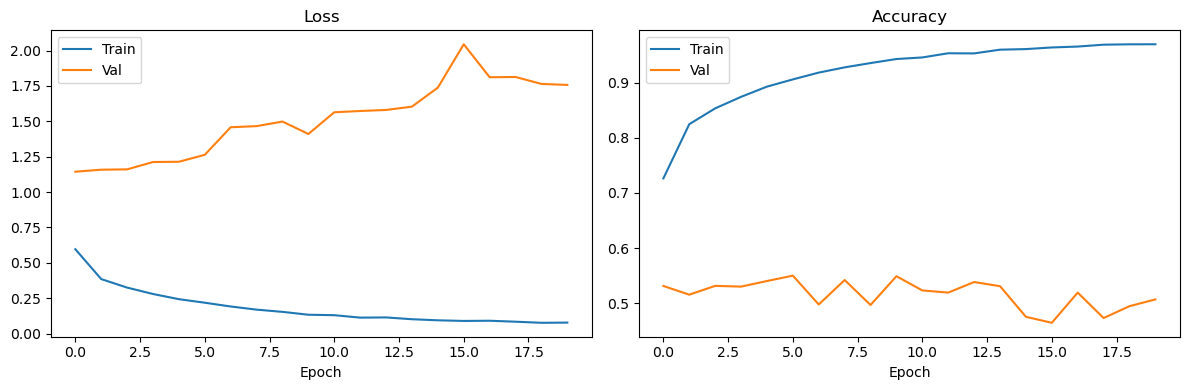

Saved → outputs/model/cnn_training_curves.png

── Classification Report ──
              precision    recall  f1-score   support

  lunges_bad       0.69      0.40      0.51      1517
 lunges_good       0.48      0.73      0.58      1430
 pullups_bad       0.25      0.28      0.26       160
pullups_good       0.71      0.86      0.78       759
 pushups_bad       0.42      0.60      0.49       439
pushups_good       0.61      0.40      0.49       539
  squats_bad       0.42      0.29      0.34       842
 squats_good       0.64      0.61      0.62       949

    accuracy                           0.55      6635
   macro avg       0.53      0.52      0.51      6635
weighted avg       0.57      0.55      0.54      6635



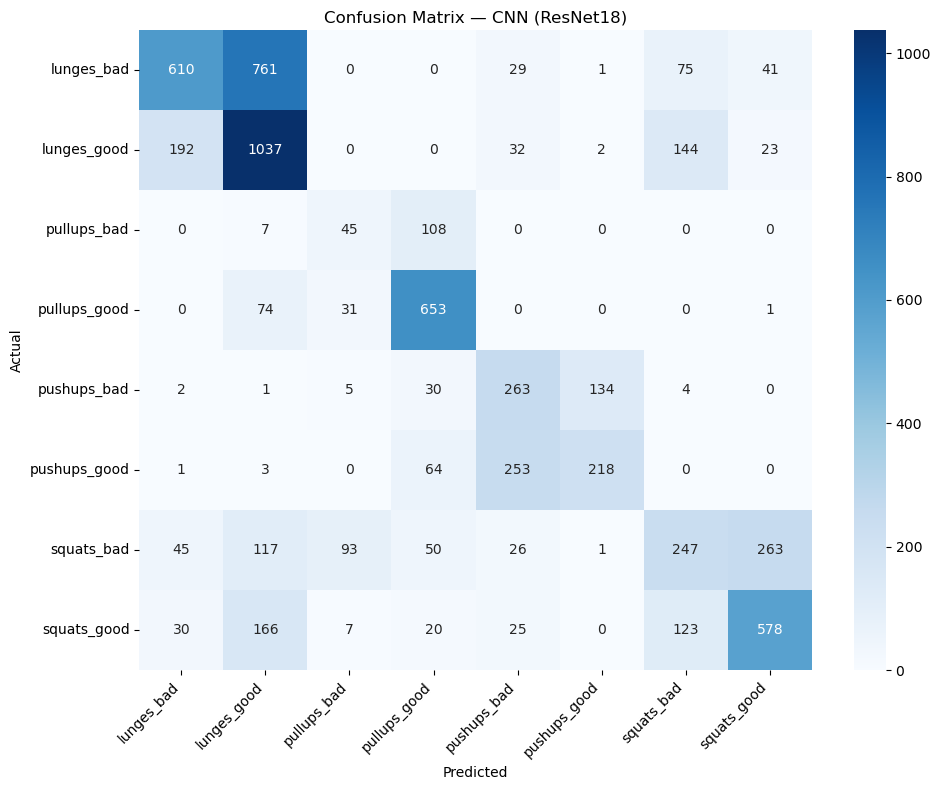

Saved → outputs/model/cnn_confusion_matrix.png
Saved label encoder → outputs/model/cnn_label_encoder.pkl


In [23]:
from torchvision import models, transforms
from PIL import Image

# ─────────────────────────────────────────────
#  Config
# ─────────────────────────────────────────────

BATCH_SIZE = 32
EPOCHS     = 20
LR         = 1e-4
NUM_WORKERS = 4
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# ─────────────────────────────────────────────
#  Dataset
# ─────────────────────────────────────────────

# ImageNet normalization — required since we use pretrained ResNet
TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

VAL_TRANSFORMS = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Include class weights in loss function
def get_class_weights(train_df, le):
    combined = (train_df["label"] + "_" + train_df["form_label"]).values
    encoded  = le.transform(combined)
    counts   = np.bincount(encoded)
    weights  = 1.0 / counts
    weights  = weights / weights.sum() * len(counts)  # normalize
    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

class FrameDataset(Dataset):
    def __init__(self, df, label_encoder, transform):
        self.df      = df.reset_index(drop=True)
        self.le      = label_encoder
        self.transform = transform

        # Combined label: e.g. "squats_good", "pushups_bad"
        self.labels = self.le.transform(
            (df["label"] + "_" + df["form_label"]).values
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        frame_path = self.df.loc[idx, "frame_path"]
        image = Image.open(frame_path).convert("RGB")
        image = self.transform(image)
        label = self.labels[idx]
        return image, label


# ─────────────────────────────────────────────
#  Load & Split Data
# ─────────────────────────────────────────────

def load_data(train_df, test_df):
    # Drop rows with missing labels
    train_df = train_df.dropna(subset=["frame_path", "label", "form_label"])
    test_df  = test_df.dropna(subset=["frame_path", "label", "form_label"])

    # Fit label encoder on all combined labels
    all_labels = pd.concat([
        train_df["label"] + "_" + train_df["form_label"],
        test_df["label"]  + "_" + test_df["form_label"]
    ]).values
    le = LabelEncoder()
    le.fit(all_labels)

    print(f"Classes     : {list(le.classes_)}")
    print(f"Train frames: {len(train_df)}")
    print(f"Test frames : {len(test_df)}\n")

    return train_df, test_df, le


# ─────────────────────────────────────────────
#  Model — Pretrained ResNet18, fine-tuned
# ─────────────────────────────────────────────

def build_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze early layers — only fine-tune last 2 blocks + classifier
    for name, param in model.named_parameters():
        if "layer3" not in name and "layer4" not in name and "fc" not in name:
            param.requires_grad = False

    # Replace final FC layer to match our number of classes
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model


# ─────────────────────────────────────────────
#  Training Loop
# ─────────────────────────────────────────────

def train_model(train_df, test_df, le):
    num_classes = len(le.classes_)

    train_dataset = FrameDataset(train_df, le, TRAIN_TRANSFORMS)
    test_dataset  = FrameDataset(test_df,  le, VAL_TRANSFORMS)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model     = build_model(num_classes).to(DEVICE)
    class_weights = get_class_weights(train_df, le)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0

    for epoch in range(1, EPOCHS + 1):
        # ── Train ──
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(images)
            loss   = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += len(labels)

        train_loss = total_loss / total
        train_acc  = correct   / total

        # ── Validate ──
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                logits    = model(images)
                loss      = criterion(logits, labels)
                val_loss += loss.item() * len(labels)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total   += len(labels)

        val_loss /= val_total
        val_acc   = val_correct / val_total
        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        # Save best model checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"{MODEL_DIR}/cnn_best.pth")
            print(f"  ✓ New best model saved (val_acc={val_acc:.4f})")

    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    return model, history


# ─────────────────────────────────────────────
#  Evaluation
# ─────────────────────────────────────────────

def evaluate_model(model, test_df, le):
    test_dataset = FrameDataset(test_df, le, VAL_TRANSFORMS)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)

    # Load best checkpoint for final evaluation
    model.load_state_dict(torch.load(f"{MODEL_DIR}/cnn_best.pth"))
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            preds  = model(images).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print("\n── Classification Report ──")
    print(classification_report(all_labels, all_preds, target_names=le.classes_))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title("Confusion Matrix — CNN (ResNet18)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{MODEL_DIR}/cnn_confusion_matrix.png", dpi=150)
    plt.show()
    print(f"Saved → {MODEL_DIR}/cnn_confusion_matrix.png")


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title("Loss")
    ax1.set_xlabel("Epoch")
    ax1.legend()

    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title("Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{MODEL_DIR}/cnn_training_curves.png", dpi=150)
    plt.show()
    print(f"Saved → {MODEL_DIR}/cnn_training_curves.png")


# ─────────────────────────────────────────────
#  Save Artifacts
# ─────────────────────────────────────────────

def save_artifacts(le):
    with open(f"{MODEL_DIR}/cnn_label_encoder.pkl", "wb") as f:
        pickle.dump(le, f)
    print(f"Saved label encoder → {MODEL_DIR}/cnn_label_encoder.pkl")


# ─────────────────────────────────────────────
#  Run
# ─────────────────────────────────────────────

train_df, test_df, le = load_data(train_df, test_df)
model, history = train_model(train_df, test_df, le)
plot_history(history)
evaluate_model(model, test_df, le)
save_artifacts(le)

## LSTM on MLP model

In [29]:
SEQ_LEN = 10   # was 30
STRIDE  = 3    # was seq_len // 2

def build_sequences(df, feature_cols, seq_len=SEQ_LEN, stride=STRIDE):
    sequences, labels = [], []
    
    for video_name, group in df.groupby("video_name"):
        group = group.sort_values("frame_index").reset_index(drop=True)
        
        if len(group) < seq_len:
            continue
        
        # Much smaller stride = many more sequences per video
        for start in range(0, len(group) - seq_len + 1, stride):
            window = group.iloc[start:start + seq_len]
            
            # Majority vote on label instead of requiring all same
            label    = window["form_label"].mode()[0]
            exercise = window["label"].iloc[0]
            
            seq = window[feature_cols].values
            sequences.append(seq)
            labels.append(f"{exercise}_{label}")
    
    return np.array(sequences), np.array(labels)

In [30]:
class PoseLSTM(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True        # sees sequence forwards and backwards
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),   # *2 for bidirectional
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, (hn, _) = self.lstm(x)
        # Concatenate final hidden state from both directions
        fwd = hn[-2]   # last layer, forward
        bwd = hn[-1]   # last layer, backward
        return self.classifier(torch.cat([fwd, bwd], dim=1))

In [31]:
def train_lstm(train_df, test_df, feature_cols, epochs=50, batch_size=32, lr=1e-3):
    X_train, y_train_raw = build_sequences(train_df, feature_cols)
    X_test,  y_test_raw  = build_sequences(test_df,  feature_cols)
    
    print(f"Train sequences: {len(X_train)}")
    print(f"Test sequences:  {len(X_test)}")

    le = LabelEncoder()
    le.fit(np.concatenate([y_train_raw, y_test_raw]))
    y_train = le.transform(y_train_raw)
    y_test  = le.transform(y_test_raw)

    # Normalize per feature across all frames
    X_flat  = X_train.reshape(-1, X_train.shape[-1])
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_flat).reshape(X_train.shape)
    X_test  = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    train_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    test_ds = torch.utils.data.TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    model     = PoseLSTM(input_dim=len(feature_cols), num_classes=len(le.classes_)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=5, factor=0.5
    )

    best_val_acc = 0.0
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent exploding gradients
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch).argmax(1)
                val_correct += (preds == y_batch).sum().item()
                val_total   += len(y_batch)

        val_acc = val_correct / val_total
        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "outputs/model/lstm_best.pth")

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Loss: {total_loss/total:.4f} | "
                  f"Val Acc: {val_acc:.4f}")

    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    return model, le, scaler

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, le, scaler = train_lstm(
    train_df, test_df,
    feature_cols=FEATURE_COLS,
    epochs=50,
    batch_size=32,
    lr=1e-3
)

Train sequences: 5400
Test sequences:  1905
Epoch  10/50 | Loss: 0.3036 | Val Acc: 0.6976
Epoch  20/50 | Loss: 0.2234 | Val Acc: 0.7034
Epoch  30/50 | Loss: 0.1485 | Val Acc: 0.7034
Epoch  40/50 | Loss: 0.1097 | Val Acc: 0.7024
Epoch  50/50 | Loss: 0.0927 | Val Acc: 0.6971

Best Val Accuracy: 0.7139


In [33]:
# Diagnose video lengths first
video_lengths = train_df.groupby("video_name")["frame_index"].count()
print(video_lengths.describe())
print(f"\nVideos with < 30 frames: {(video_lengths < 30).sum()}")
print(f"Videos with < 15 frames: {(video_lengths < 15).sum()}")
print(f"Videos with < 10 frames: {(video_lengths < 10).sum()}")

count    316.000000
mean      59.360759
std       34.542583
min        7.000000
25%       34.000000
50%       50.000000
75%       87.000000
max      132.000000
Name: frame_index, dtype: float64

Videos with < 30 frames: 65
Videos with < 15 frames: 11
Videos with < 10 frames: 3


## XGBoost

[0]	validation_0-mlogloss:1.85909


/home/amchahal/.local/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [23:06:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-mlogloss:0.84047
[100]	validation_0-mlogloss:0.69231
[150]	validation_0-mlogloss:0.67912
[200]	validation_0-mlogloss:0.69409
[250]	validation_0-mlogloss:0.71836
[299]	validation_0-mlogloss:0.73925

── XGBoost Classification Report ──
              precision    recall  f1-score   support

  lunges_bad       0.72      0.79      0.75      1517
 lunges_good       0.76      0.90      0.82      1430
 pullups_bad       0.62      0.69      0.65       160
pullups_good       0.76      0.72      0.74       759
 pushups_bad       0.74      0.95      0.83       439
pushups_good       0.93      0.90      0.92       539
  squats_bad       0.86      0.58      0.70       842
 squats_good       0.74      0.58      0.65       949

    accuracy                           0.76      6635
   macro avg       0.77      0.76      0.76      6635
weighted avg       0.77      0.76      0.76      6635



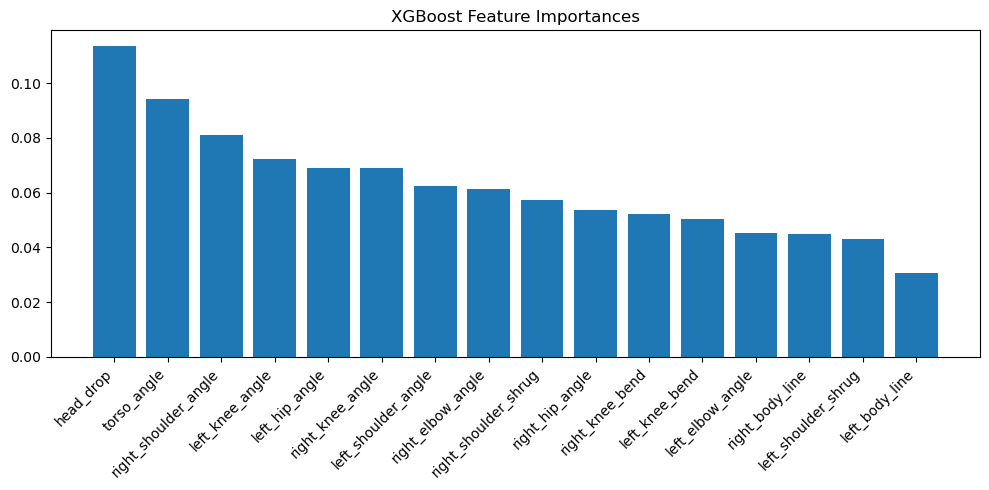

In [35]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Reuse your existing X_train, X_test, y_train, y_test, le from the MLP pipeline
# If you need to rebuild:
# X_train, X_test, y_train, y_test, le, scaler = load_data(train_df, test_df)

# ── XGBoost ──────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50           # print every 50 rounds
)

y_pred = xgb.predict(X_test)
print("\n── XGBoost Classification Report ──")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── Feature importance ───────────────────────────────────────
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
indices     = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(FEATURE_COLS)), importances[indices])
plt.xticks(range(len(FEATURE_COLS)), [FEATURE_COLS[i] for i in indices], rotation=45, ha="right")
plt.title("XGBoost Feature Importances")
plt.tight_layout()
plt.savefig("outputs/model/xgb_feature_importance.png", dpi=150)
plt.show()

## Transformer

In [36]:
from torch.utils.data import TensorDataset

# ── Model ────────────────────────────────────────────────────
class PoseTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, 64)
        self.pos_encoding = nn.Parameter(torch.randn(1, 100, 64))  # learnable positional encoding
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=num_heads, dropout=dropout,
            dim_feedforward=256, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)                        # (batch, seq, 64)
        x = x + self.pos_encoding[:, :x.size(1), :]  # add positional encoding
        x = self.transformer(x)                        # (batch, seq, 64)
        x = x.mean(dim=1)                             # global average pool
        return self.classifier(x)


# ── Build sequences (reuse from LSTM) ────────────────────────
SEQ_LEN = 20
STRIDE  = 5

X_train_seq, y_train_raw = build_sequences(train_df, FEATURE_COLS, seq_len=SEQ_LEN, stride=STRIDE)
X_test_seq,  y_test_raw  = build_sequences(test_df,  FEATURE_COLS, seq_len=SEQ_LEN, stride=STRIDE)

print(f"Train sequences: {len(X_train_seq)}")
print(f"Test sequences:  {len(X_test_seq)}")

# Normalize
X_flat  = X_train_seq.reshape(-1, X_train_seq.shape[-1])
scaler_seq = StandardScaler()
X_train_seq = scaler_seq.fit_transform(X_flat).reshape(X_train_seq.shape)
X_test_seq  = scaler_seq.transform(
    X_test_seq.reshape(-1, X_test_seq.shape[-1])
).reshape(X_test_seq.shape)

# Encode labels
le_seq = LabelEncoder()
le_seq.fit(np.concatenate([y_train_raw, y_test_raw]))
y_train_enc = le_seq.transform(y_train_raw)
y_test_enc  = le_seq.transform(y_test_raw)

# Dataloaders
train_ds = TensorDataset(
    torch.tensor(X_train_seq, dtype=torch.float32),
    torch.tensor(y_train_enc, dtype=torch.long)
)
test_ds = TensorDataset(
    torch.tensor(X_test_seq, dtype=torch.float32),
    torch.tensor(y_test_enc, dtype=torch.long)
)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# ── Train ─────────────────────────────────────────────────────
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_tr  = PoseTransformer(input_dim=len(FEATURE_COLS), num_classes=len(le_seq.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_tr.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5
)

best_val_acc = 0.0
EPOCHS = 50

for epoch in range(1, EPOCHS + 1):
    model_tr.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model_tr(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model_tr.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    model_tr.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model_tr(X_batch).argmax(1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    val_acc = val_correct / val_total
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_tr.state_dict(), "outputs/model/transformer_best.pth")

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Loss: {total_loss/total:.4f} | "
              f"Val Acc: {val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

# ── Evaluation ────────────────────────────────────────────────
model_tr.load_state_dict(torch.load("outputs/model/transformer_best.pth"))
model_tr.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model_tr(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("\n── Transformer Classification Report ──")
print(classification_report(all_labels, all_preds, target_names=le_seq.classes_))

Train sequences: 2690
Test sequences:  943
Epoch  10/50 | Loss: 0.4030 | Val Acc: 0.7402
Epoch  20/50 | Loss: 0.2603 | Val Acc: 0.7285
Epoch  30/50 | Loss: 0.2118 | Val Acc: 0.7413
Epoch  40/50 | Loss: 0.1908 | Val Acc: 0.7413
Epoch  50/50 | Loss: 0.1947 | Val Acc: 0.7402

Best Val Accuracy: 0.7773

── Transformer Classification Report ──
              precision    recall  f1-score   support

  lunges_bad       0.78      0.68      0.72       245
 lunges_good       0.83      0.93      0.88       227
 pullups_bad       0.20      0.40      0.27         5
pullups_good       0.87      0.97      0.92       104
 pushups_bad       0.85      0.52      0.65        44
pushups_good       0.74      0.98      0.84        63
  squats_bad       0.62      0.71      0.66       115
 squats_good       0.81      0.62      0.70       140

    accuracy                           0.78       943
   macro avg       0.71      0.73      0.71       943
weighted avg       0.78      0.78      0.77       943

